kaggle 比赛：[CIFAR-10 - Object Recognition in Images](https://www.kaggle.com/competitions/cifar-10) .

CIFAR-10  is an established computer-vision dataset used for object recognition. It is a subset of the 80 million tiny images dataset and consists of 60,000 32x32 color images containing one of 10 object classes, with 6000 images per class. It was collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton.

![pic](https://storage.googleapis.com/kaggle-media/competitions/kaggle/3649/media/cifar-10.png)

很离谱：

> To discourage certain forms of cheating (such as hand labeling) we have added 290,000 junk images in the test set. These images are ignored in the scoring. We have also made trivial modifications to the official 10,000 test images to prevent looking them up by file hash. These modifications should not appreciably affect the scoring. You should predict labels for all 300,000 images.

The label classes in the dataset are:
- airplane 
- automobile 
- bird 
- cat 
- deer 
- dog 
- frog 
- horse 
- ship 
- truck

The classes are completely mutually exclusive. There is no overlap between automobiles and trucks. "Automobile" includes sedans, SUVs, things of that sort. "Truck" includes only big trucks. Neither includes pickup trucks.

In [3]:
!python3 --version

Python 3.11.11


In [4]:
!nvidia-smi

Sat Jul  5 08:07:34 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sklearn
import sys
import tensorflow as tf

from tensorflow import keras

print(tf.__version__)
print(sys.version_info)
for module in mpl, np, pd, sklearn, tf, keras:
    print(module.__name__, module.__version__)

2025-07-05 08:07:36.579977: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751702856.791299      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751702856.850841      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2.18.0
sys.version_info(major=3, minor=11, micro=11, releaselevel='final', serial=0)
matplotlib 3.7.2
numpy 1.26.4
pandas 2.2.3
sklearn 1.2.2
tensorflow 2.18.0
keras._tf_keras.keras 3.8.0


In [6]:
import tensorflow as tf

print(f"TensorFlow Version: {tf.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")

if gpus:
    print(f"GPUs available: {gpus}")
    try:
        # 打印每个GPU的详细信息
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True) # 推荐设置，按需分配显存
            print(f"Details for {gpu.name}:")
            # 可以尝试执行一个小操作来确认
        print("GPU is available and TensorFlow can see it!")

        # 尝试一个简单的GPU运算
        print("\nAttempting a simple computation on GPU...")
        with tf.device('/GPU:0'): # 明确指定在第一个GPU上运行
            a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
            b = tf.constant([[1.0, 2.0], [3.0, 4.0]])
            c = tf.matmul(a, b)
        print("Matrix multiplication result from GPU:")
        print(c.numpy())
        print("If no errors occurred, GPU is working!")

    except RuntimeError as e:
        print(f"RuntimeError during GPU setup or test: {e}")
else:
    print("GPU not available to TensorFlow. TensorFlow will run on CPU.")

TensorFlow Version: 2.18.0
Num GPUs Available: 2
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Details for /physical_device:GPU:0:
Details for /physical_device:GPU:1:
GPU is available and TensorFlow can see it!

Attempting a simple computation on GPU...
Matrix multiplication result from GPU:
[[ 7. 10.]
 [15. 22.]]
If no errors occurred, GPU is working!


I0000 00:00:1751702869.120295      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1751702869.120953      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


注意在 kaggle 上的文件操作：

![pic](./6.png)

In [7]:
!ls ../input/cifar-10

sampleSubmission.csv  test.7z  train.7z  trainLabels.csv


In [8]:
%pip install py7zr
import py7zr
a = py7zr.SevenZipFile(r'../input/cifar-10/train.7z', 'r')
a.extractall(path=r'./')
a.close()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 52.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.3/141.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.9/412.9 kB 24.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [9]:
with py7zr.SevenZipFile('../input/cifar-10/test.7z', 'r') as archive:
    archive.extractall(path='./')

In [10]:
!ls

test  train


In [11]:
# 所有的类别
class_names = [  # 不要乱序！
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck',
]

def parse_csv_file(filepath, folder):
    """Parses csv files into (filename(path), label) format"""
    results = []
    # 读取所有行
    with open(filepath, 'r') as f:
        lines = f.readlines()[1:]
    for line in lines:
        image_id, label_str = line.strip('\n').split(',')
        image_full_path = os.path.join(folder, image_id + '.png')
        results.append((image_full_path, label_str)) # 得到对应图片的路径和标签
    return results

In [12]:
# ------------------ 步骤 1: 定义正确的图片文件夹路径 ------------------
train_folder_after_extraction = 'train/'
test_folder_after_extraction = 'test/'

# ------------------ 步骤 2: 解析CSV，生成正确的文件路径列表 ------------------
train_lables_file = '../input/cifar-10/trainLabels.csv'
test_csv_file = '../input/cifar-10/sampleSubmission.csv'

# 使用上面定义好的、正确的文件夹路径
train_labels_info = parse_csv_file(train_lables_file, train_folder_after_extraction)
test_csv_info = parse_csv_file(test_csv_file, test_folder_after_extraction) # 预测时会用到

# ------------------ 步骤 3: 创建并分割 DataFrame ------------------
# 这一步必须在创建 generator 之前
all_train_df = pd.DataFrame(train_labels_info)
all_train_df.columns = ['filepath', 'class']

test_df = pd.DataFrame(test_csv_info)
test_df.columns = ['filepath', 'class']

# 分割为训练集和验证集
train_df = all_train_df.iloc[0:45000]
valid_df = all_train_df.iloc[45000:]

# ------------------ 步骤 4: 定义数据增强并创建 Generator ------------------
height = 32
width = 32
channels = 3
batch_size = 32
num_classes = 10

# 训练集的数据增强设置
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
)

# 使用修正后的 train_df 创建 train_generator
# directory=None 告诉生成器，'filepath' 列中的路径已经是完整的了，不需要再拼接
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=None,
    x_col='filepath',
    y_col='class',
    classes=class_names,
    target_size=(height, width),
    batch_size=batch_size,
    seed=7,
    shuffle=True,
    class_mode='sparse',
)

# 验证集不需要数据增强，只需归一化
valid_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# 使用修正后的 valid_df 创建 valid_generator
valid_generator = valid_datagen.flow_from_dataframe(
    valid_df,
    directory=None,
    x_col='filepath',
    y_col='class',
    classes=class_names,
    target_size=(height, width),
    batch_size=batch_size,
    seed=7,
    shuffle=False,
    class_mode="sparse")

# 检查是否成功找到了图片
train_num = train_generator.samples
valid_num = valid_generator.samples
print(f"训练集找到 {train_num} 张图片，验证集找到 {valid_num} 张图片。")

Found 45000 validated image filenames belonging to 10 classes.
Found 5000 validated image filenames belonging to 10 classes.
训练集找到 45000 张图片，验证集找到 5000 张图片。


In [ ]:
test_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=None,  # 路径已经是完整的
    x_col='filepath',
    y_col='class',     # y_col 是必需的，但其值在预测时无所谓
    class_mode=None, # 预测时不需要标签，设为 None
    target_size=(height, width),
    batch_size=batch_size,
    shuffle=False    # 预测时一定不要打乱顺序！
)

print(f"测试集找到 {test_generator.n} 张图片。")

Found 300000 validated image filenames.
测试集找到 300000 张图片。


In [14]:
for i in range(2):
    x, y = next(train_generator)
    print(x.shape, y.shape)
    print(y)

(32, 32, 32, 3) (32,)
[2. 1. 4. 4. 4. 4. 6. 5. 2. 8. 4. 6. 6. 3. 7. 1. 7. 2. 8. 8. 3. 0. 5. 3.
 9. 1. 4. 5. 6. 7. 9. 2.]
(32, 32, 32, 3) (32,)
[0. 7. 2. 7. 5. 5. 7. 0. 5. 4. 9. 7. 6. 3. 0. 4. 4. 4. 6. 3. 5. 4. 6. 6.
 4. 1. 8. 2. 4. 4. 3. 0.]


In [15]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=128, kernel_size=3, padding='same',
                        activation='relu', 
                        input_shape=[width, height, channels]),
    keras.layers.BatchNormalization(),#为了是模型训练的更快
    keras.layers.Conv2D(filters=128, kernel_size=3, padding='same',
                        activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=2),
    
    keras.layers.Conv2D(filters=256, kernel_size=3, padding='same',
                        activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256, kernel_size=3, padding='same',
                        activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Conv2D(filters=512, kernel_size=3, padding='same',
                        activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=512, kernel_size=3, padding='same',
                        activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax'),
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam", metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 8,783,498 (33.51 MB)

 Trainable params: 8,779,914 (33.49 MB)

 Non-trainable params: 3,584 (14.00 KB)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 87 not upgraded.


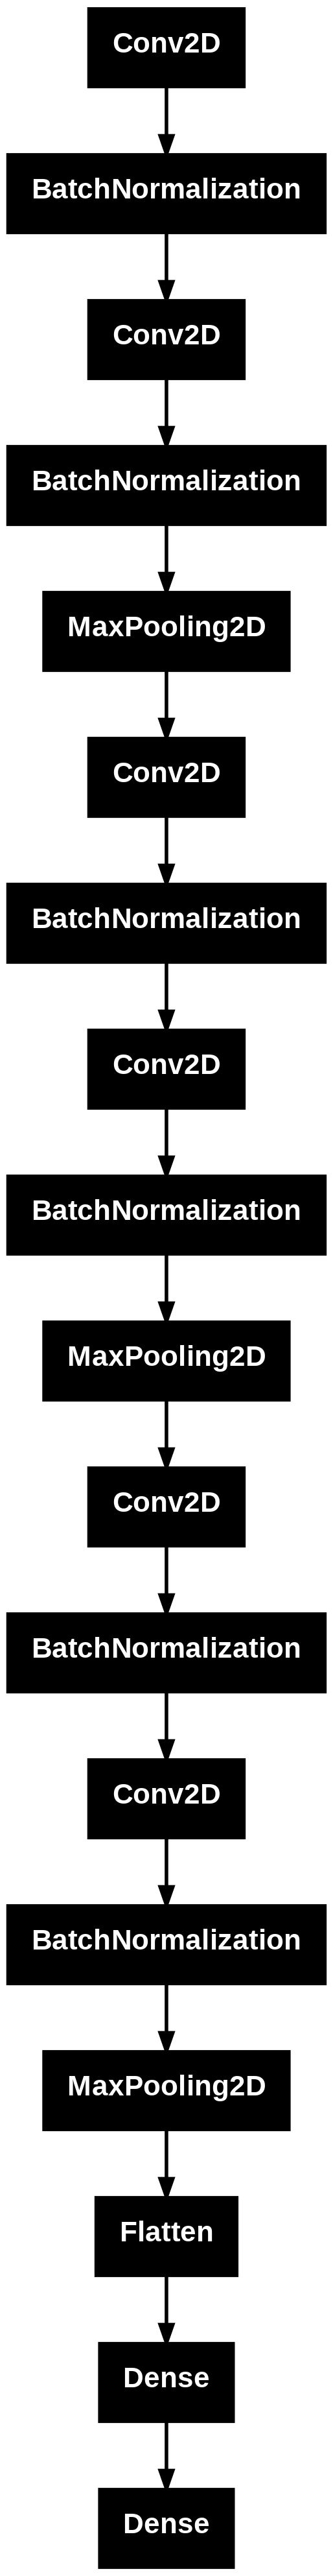

In [16]:
!sudo apt-get install graphviz -y
from tensorflow.keras.utils import plot_model
plot_model(model)

In [17]:
epochs = 20
history = model.fit(train_generator,
                    steps_per_epoch = train_num // batch_size,
                    epochs = epochs,
                    validation_data = valid_generator,
                    validation_steps = valid_num // batch_size)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1751703029.797986     101 service.cc:148] XLA service 0x7afe14003420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751703029.798799     101 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1751703029.798823     101 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1751703030.433207     101 cuda_dnn.cc:529] Loaded cuDNN version 90300


   5/1406 ━━━━━━━━━━━━━━━━━━━━ 53s 38ms/step - accuracy: 0.0667 - loss: 12.8956 

I0000 00:00:1751703036.173970     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1406/1406 ━━━━━━━━━━━━━━━━━━━━ 64s 37ms/step - accuracy: 0.2809 - loss: 2.9114 - val_accuracy: 0.3920 - val_loss: 1.7535
Epoch 2/20
   1/1406 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.2500 - loss: 1.8487

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1406/1406 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2500 - loss: 1.8487 - val_accuracy: 0.3868 - val_loss: 1.7928
Epoch 3/20
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.4509 - loss: 1.5154 - val_accuracy: 0.4519 - val_loss: 1.6568
Epoch 4/20
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3750 - loss: 1.4474 - val_accuracy: 0.4315 - val_loss: 1.7784
Epoch 5/20
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.5345 - loss: 1.3031 - val_accuracy: 0.5172 - val_loss: 1.5126
Epoch 6/20
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3125 - loss: 1.7920 - val_accuracy: 0.5070 - val_loss: 1.5595
Epoch 7/20
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.6044 - loss: 1.1262 - val_accuracy: 0.6671 - val_loss: 0.9882
Epoch 8/20
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7500 - loss: 0.9007 - val_accuracy: 0.6703 - val_loss: 0.9830
Epoch 9/20
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.6555 - loss: 0.9970 - val

{'accuracy': [0.3465130627155304, 0.25, 0.471312940120697, 0.375, 0.551369845867157, 0.3125, 0.6152597665786743, 0.75, 0.6626712083816528, 0.75, 0.6997865438461304, 0.6875, 0.7295187711715698, 0.6875, 0.7495329976081848, 0.75, 0.7679461240768433, 0.6875, 0.7797322273254395, 0.71875], 'loss': [2.0006091594696045, 1.8487098217010498, 1.4611661434173584, 1.4473962783813477, 1.2610352039337158, 1.7920008897781372, 1.1056716442108154, 0.9006525278091431, 0.979647159576416, 0.7844924926757812, 0.8713200688362122, 0.7984549403190613, 0.7884455919265747, 0.8797010183334351, 0.7362867593765259, 0.6853671073913574, 0.6851825714111328, 0.9326616525650024, 0.6482270359992981, 0.7139627933502197], 'val_accuracy': [0.39202722907066345, 0.38681891560554504, 0.45192307233810425, 0.43149039149284363, 0.5172275900840759, 0.5070112347602844, 0.667067289352417, 0.6702724099159241, 0.7239583134651184, 0.7193509340286255, 0.7624198794364929, 0.7630208134651184, 0.7423878312110901, 0.7445913553237915, 0.7271

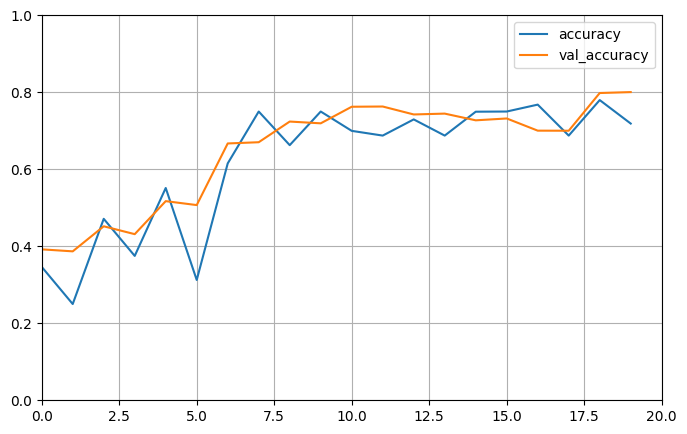

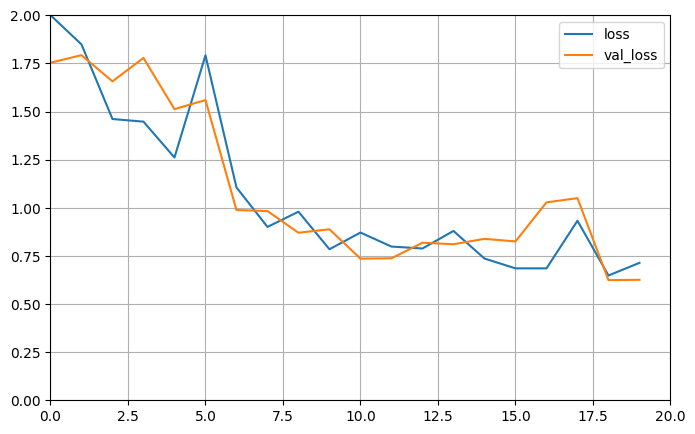

In [18]:
print(history.history)
def plot_learning_curves(history, label, epcohs, min_value, max_value):
    data = {}
    data[label] = history.history[label]
    data['val_'+label] = history.history['val_'+label]
    pd.DataFrame(data).plot(figsize=(8, 5))
    plt.grid(True)
    plt.axis([0, epochs, min_value, max_value])
    plt.show()
    
plot_learning_curves(history, 'accuracy', epochs, 0, 1)
plot_learning_curves(history, 'loss', epochs, 0, 2)

In [19]:
# 运行时间很久，需要 GPU
test_predict = model.predict(test_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9375/9375 ━━━━━━━━━━━━━━━━━━━━ 90s 10ms/step


In [20]:
print(test_predict.shape)

(300000, 10)


In [21]:
# 每一个样本预测输出的是 10 个概率值
print(test_predict[0:5])

[[1.0881534e-01 1.6718476e-01 9.5134318e-02 4.8246849e-02 3.8943909e-02
  2.4931163e-02 6.5240808e-02 5.6113526e-02 6.1206609e-02 3.3418277e-01]
 [2.9309273e-01 1.7695334e-04 6.4493966e-01 1.0800979e-02 4.9136457e-04
  5.7730608e-04 1.1314030e-02 5.0933624e-04 3.7483163e-02 6.1457016e-04]
 [6.1910246e-06 9.9097884e-01 9.8316974e-08 1.1196201e-07 1.2110615e-08
  2.4635506e-07 1.0491385e-06 1.2073046e-06 2.1313648e-05 8.9910878e-03]
 [1.1243846e-05 1.0804900e-04 9.2857317e-07 9.6682379e-07 1.6999894e-07
  2.2695627e-07 7.2568821e-07 1.7356791e-07 9.9986959e-01 7.8575649e-06]
 [1.4330401e-01 2.0093690e-05 8.3951026e-01 5.9665660e-03 4.9000545e-03
  1.1120881e-03 2.7876063e-03 1.6545020e-03 5.6291645e-04 1.8190715e-04]]


In [22]:
# 一个向量中哪个的值最大，返回其下标
test_predict_class_indices = np.argmax(test_predict, axis = 1)

In [23]:
print(test_predict_class_indices[0:5])

[9 2 1 8 2]


In [24]:
test_predict_class = [class_names[index] 
                      for index in test_predict_class_indices]

In [25]:
print(test_predict_class[0:5])

['truck', 'bird', 'automobile', 'ship', 'bird']


In [26]:
# 产生最终的报告
def generate_submissions(filename, predict_class):
    with open(filename, 'w') as f:
        f.write('id,label\n')
        for i in range(len(predict_class)):
            f.write('%d,%s\n' % (i+1, predict_class[i]))

# output_file = "../input/cifar-10/submission.csv"
output_file = "./submission.csv"
generate_submissions(output_file, test_predict_class)

In [27]:
!ls

model.png  submission.csv  test  train


结果：

![pic](./7.png)